<a href="https://colab.research.google.com/github/sohagcode/AI/blob/main/AI_LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

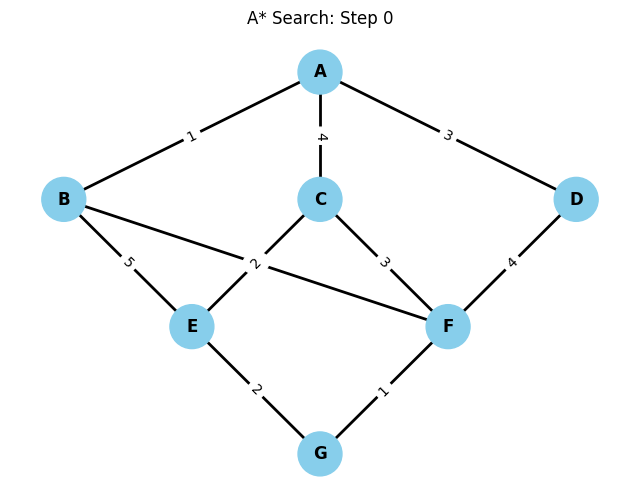

------------------------------
Expanded: A
g= 0
h= 7
f= 7


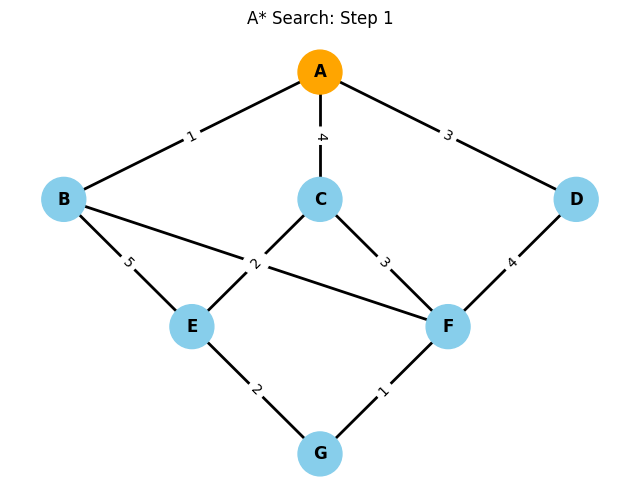

B: g=1,h=6,f=7
C: g=4,h=4,f=8
D: g=3,h=5,f=8

Optimal Path: None
Total Cost: None


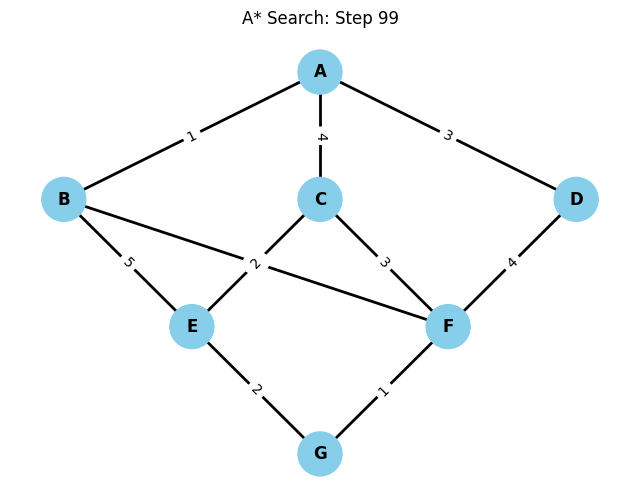

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

graph={
    'A':[('B',1),('C',4),('D',3)],
    'B':[('A',1),('E',5),('F',2)],
    'C':[('A',4),('E',2),('F',3)],
    'D':[('A',3),('F',4)],
    'E':[('B',5),('C',2),('G',2)],
    'F':[('B',2),('C',3),('D',4),('G',1)],
    'G':[('E',2),('F',1)]
}

heuristic={
    'A':7,
    'B':6,
    'C':4,
    'D':5,
    'E':3,
    'F':1,
    'G':0
}

pos={
    'A':(2,4),
    'B':(0,2),
    'C':(2,2),
    'D':(4,2),
    'E':(1,0),
    'F':(3,0),
    'G':(2,-2)
}


G=nx.Graph()

for node in graph:
  for neigh, cost in graph[node]:
    G.add_edge(node,neigh,weight=cost)

def draw_graph(current=None, path=None,step=0):
  plt.figure(figsize=(8,6))
  node_colors=[]
  for n in G.nodes():
    if path and n in path:
      node_colors.append("limegreen")
    elif n==current:
      node_colors.append("orange")
    else:
      node_colors.append("skyblue")
  nx.draw_networkx_nodes(
    G,pos,
    node_color = node_colors,
    node_size=1000
)
  nx.draw_networkx_labels(
    G,pos,
    font_size=12,
    font_weight='bold'
)
  nx.draw_networkx_edges(G,pos,width=2)

  edge_labels=nx.get_edge_attributes(G,'weight')
  nx.draw_networkx_edge_labels(
       G,pos,
       edge_labels=edge_labels
)
  if path is not None:
   edges=[]
   for i in range(len(path)-1):
    edges.append((path[i],path[i+1]))

   nx.draw_networkx_edges(
       G,pos,
       edgelist=edges,
       edge_color='green',
       width=4
  )
  plt.title(f"A* Search: Step {step}")
  plt.axis('off')
  plt.savefig(f"step_{step}.png")
  plt.show()


draw_graph(step=0)

def astar(start,goal):
    pq=[]
    heapq.heappush(
        pq,
        (heuristic[start],0,start,[start])
    )
    visited={}
    step=1
    while pq:
      f,g,node,path=heapq.heappop(pq)
      print("------------------------------")
      print("Expanded:", node)
      print("g=", g)
      print("h=",heuristic[node])
      print("f=",f)

      draw_graph(current=node,step=step)
      step+=1

      if node==goal:
        return path, g
      if node in visited and visited[node]<=g:
        continue

      visited[node]=g

      for neigh, cost in graph[node]:
        new_g=g+cost
        new_f=new_g+heuristic[neigh]
        heapq.heappush(
            pq,
            (new_f,new_g,neigh,path+[neigh])
        )
        print(
            f"{neigh}: g={new_g},"
            f"h={heuristic[neigh]},"
            f"f={new_f}"
         )
      return None,None
path,cost=astar('A','G')
print("\nOptimal Path:",path)
print("Total Cost:",cost)

draw_graph(path=path,step=99)